# Filament Segmentation Pipeline

This notebook implements a data analysis pipeline for segmenting **brighter spots** (filaments) in microscopy images. We compare several classical image processing methods.

**Pipeline overview:**
1. Load raw multi-frame TIFF images from `workflow/data/`
2. Exploratory data analysis
3. Apply multiple segmentation methods
4. Visualise results

---
## 1. Setup and Configuration

We import the workflow classes from the `workflow` package and set the path to the raw image data. The dataset consists of multi-frame TIFF files (~900 frames per file) in the `workflow/data/` directory.

In [70]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# Project root: directory containing workflow package (handles cwd = workspace root)
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "workflow" / "__init__.py").exists():
    PROJECT_ROOT = Path.cwd() / "BioHackathon2026"
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from workflow import (
    RawImageLoader,
    DatasetNormalizer,
    OtsuSegmenter,
    AdaptiveThresholdSegmenter,
    MorphologicalSegmenter,
    WatershedSegmenter,
    TopHatSegmenter,
    CLAHEThresholdSegmenter,
)
from workflow.experiments import (
    SampleCollector,
    SampleGridVisualizer,
    SegmentationVisualizer,
    AdaptiveParameterScan,
)

# Path to raw multi-frame TIFF files (~900 frames per file)
DATA_DIR = PROJECT_ROOT / "workflow" / "data"

print(f"Data directory: {DATA_DIR}")
print(f"Exists: {DATA_DIR.exists()}")

Data directory: /home/marmatt/Documents/BioHackathon2026/workflow/data
Exists: True


---
## 2. Load Dataset

We use `RawImageLoader` to load multi-frame TIFF files from the data directory. Each file contains ~900 frames; we can limit how many frames to load per file for faster iteration.

In [71]:
loader = RawImageLoader(str(DATA_DIR))

print(f"Number of TIFF files: {len(loader.files)}")
print(f"Total frames (all files): {len(loader)}")
if loader.files:
    n = loader.get_frame_count(loader.files[0])
    print(f"Frames in first file ({loader.files[0].name}): {n}")

Number of TIFF files: 9
Total frames (all files): 900
Frames in first file (ch20_URA7_URA8_001-crop1.tif): 100


---
## 3. Data visualisation

We first visualise the images using `SampleGridVisualiser` to see what data we are dealing with.

In [72]:
import contextlib
import io

with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
    samples = SampleCollector(loader, max_total=20).run()

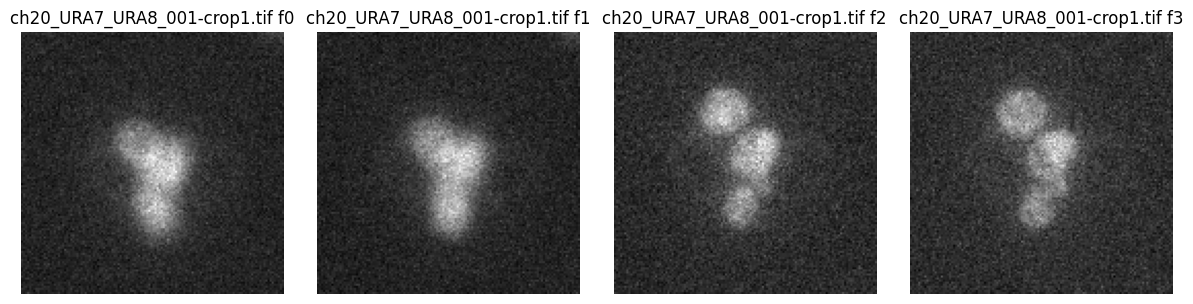

In [73]:
SampleGridVisualizer(samples, n_display=4).run()

---
## 4. Pre-processing

We normalize all loaded samples to a consistent intensity range before segmentation.

In [74]:
samples = DatasetNormalizer(samples).run()

---
## 11. Evaluation

We evaluate segmentation methods against human-annotated **ground truth** from Label Studio (`export_244107_project-244107-at-2026-03-21-11-44-ab41ab26.json`). Methods include Ilastik (thresholded probability maps), SAM2, and MorphologicalSegmenter. The evaluation measures:

1. **Detection** — whether the method correctly identifies frames containing a filament
2. **Segmentation overlap** — pixel overlap (IoU, Dice) and boundary alignment (boundary Dice)
3. **Segmentation specificity** — minimal spillage outside the ground-truth polygon


In [75]:
# SAM2 and MorphologicalSegmenter defined in following cells
pass


In [76]:
# Method 2: SAM2 plain p1 no box — build predictor and FrangiSAM2Segmenter
import sys
from pathlib import Path
from typing import Optional
from skimage import morphology

if str(PROJECT_ROOT / "TestSetRawTIF") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "TestSetRawTIF"))

from workflow.segmentation import BaseSegmenter

def build_sam2_image_predictor(model_cfg: str, checkpoint_path: Path, device: Optional[str] = None):
    try:
        import torch
        from sam2.build_sam import build_sam2
        from sam2.sam2_image_predictor import SAM2ImagePredictor
    except Exception as e:
        raise ImportError("SAM2 import failed.") from e
    if not checkpoint_path.exists():
        raise FileNotFoundError(f"SAM2 checkpoint not found: {checkpoint_path}")
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"
    model = build_sam2(model_cfg, str(checkpoint_path), device=device)
    predictor = SAM2ImagePredictor(model)
    return predictor, device

class FrangiSAM2Segmenter(BaseSegmenter):
    def __init__(self, predictor, sigmas=(1, 2, 3, 4), frangi_threshold_percentile=80,
                 prompt_count=1, use_box_prompt=False, fusion_mode="plain", min_size=20):
        self.predictor, self.sigmas = predictor, sigmas
        self.frangi_threshold_percentile = frangi_threshold_percentile
        self.prompt_count, self.use_box_prompt, self.fusion_mode, self.min_size = prompt_count, use_box_prompt, fusion_mode, min_size

    @staticmethod
    def _to_rgb_uint8(image):
        img = np.asarray(image, dtype=np.float32)
        m = float(img.max()) if img.size else 0.0
        if m > 0:
            img = img / m
        img_u8 = (np.clip(img, 0, 1) * 255).astype(np.uint8)
        return np.stack([img_u8, img_u8, img_u8], axis=-1)

    def _frangi_prior(self, image):
        from skimage import filters
        img = np.asarray(image, dtype=np.float64)
        if img.max() > 1.0:
            img = img / img.max()
        response = filters.frangi(img, sigmas=self.sigmas, black_ridges=False)
        nonzero = response[response > 0]
        if len(nonzero) == 0:
            return response, np.zeros_like(img, dtype=np.uint8)
        thr = np.percentile(nonzero, self.frangi_threshold_percentile)
        prior = (response >= thr).astype(np.uint8)
        return response, prior

    def _prompt_points(self, response, prior):
        ys, xs = np.where(prior > 0)
        if len(xs) == 0:
            return None, None
        vals = response[ys, xs]
        order = np.argsort(vals)[::-1]
        selected = []
        min_sq_dist = 16.0
        for idx in order:
            x, y = float(xs[idx]), float(ys[idx])
            if all((x - sx) ** 2 + (y - sy) ** 2 >= min_sq_dist for sx, sy in selected):
                selected.append((x, y))
            if len(selected) >= self.prompt_count:
                break
        if not selected:
            selected = [(float(xs[order[0]]), float(ys[order[0]]))]
        return np.asarray(selected, dtype=np.float32), np.ones((len(selected),), dtype=np.int32)

    @staticmethod
    def _prior_box(prior):
        ys, xs = np.where(prior > 0)
        if len(xs) == 0:
            return None
        return np.asarray([xs.min(), ys.min(), xs.max(), ys.max()], dtype=np.float32)

    def _fuse(self, sam_mask, prior):
        sam_bin, prior_bin = sam_mask.astype(bool), prior.astype(bool)
        if self.fusion_mode == "plain":
            fused = sam_bin
        elif self.fusion_mode == "strict":
            fused = sam_bin & morphology.binary_dilation(prior_bin, morphology.disk(1))
        elif self.fusion_mode == "loose":
            wide = morphology.binary_dilation(prior_bin, morphology.disk(4))
            fused = (sam_bin & wide) | prior_bin
        else:
            raise ValueError(f"Unknown fusion_mode: {self.fusion_mode}")
        if self.min_size > 0:
            fused = morphology.remove_small_objects(fused, min_size=self.min_size)
        return fused.astype(np.uint8)

    def segment(self, image):
        response, prior = self._frangi_prior(image)
        if prior.sum() == 0:
            return prior
        point_coords, point_labels = self._prompt_points(response, prior)
        if point_coords is None:
            return np.zeros_like(prior, dtype=np.uint8)
        box = self._prior_box(prior) if self.use_box_prompt else None
        rgb = self._to_rgb_uint8(image)
        self.predictor.set_image(rgb)
        masks, scores, _ = self.predictor.predict(point_coords=point_coords, point_labels=point_labels,
            box=None if box is None else box[None, :], multimask_output=True)
        if len(masks) == 0:
            return np.zeros_like(prior, dtype=np.uint8)
        best_mask = masks[int(np.argmax(scores))]
        return self._fuse(best_mask, prior)

sam2_predictor = None
try:
    from urllib.request import urlretrieve
    ROOT = PROJECT_ROOT.resolve()
    SAM2_DIR = ROOT / "models" / "sam2"
    SAM2_DIR.mkdir(parents=True, exist_ok=True)
    SAM2_MODEL_CFG = "configs/sam2.1/sam2.1_hiera_l.yaml"
    SAM2_CHECKPOINT_PATH = SAM2_DIR / "sam2.1_hiera_large.pt"
    SAM2_CHECKPOINT_URL = "https://dl.fbaipublicfiles.com/segment_anything_2/092824/sam2.1_hiera_large.pt"
    if not SAM2_CHECKPOINT_PATH.exists():
        print(f"Downloading SAM2 checkpoint -> {SAM2_CHECKPOINT_PATH}")
        urlretrieve(SAM2_CHECKPOINT_URL, SAM2_CHECKPOINT_PATH)
    sam2_predictor, SAM2_DEVICE = build_sam2_image_predictor(SAM2_MODEL_CFG, SAM2_CHECKPOINT_PATH)
    print(f"SAM2 ready on {SAM2_DEVICE}")
except Exception as e:
    print(f"SAM2 not available: {e}. Method 2 will be skipped.")


SAM2 ready on cuda


In [77]:
# Load evaluation dataset: images from Combined, ground truth from Label Studio JSON
import sys
from pathlib import Path
import imageio.v3 as iio
import numpy as np

if str(PROJECT_ROOT / "TestSetRawTIF") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "TestSetRawTIF"))
from overlay_labels_from_export import build_frame_to_annotations_map, extract_frame_index

TEST_DIR = PROJECT_ROOT / "TestSetRawTIF"
if not TEST_DIR.exists():
    TEST_DIR = PROJECT_ROOT.parent / "BioHackathon2026" / "TestSetRawTIF"
COMBINED_DIR = TEST_DIR / "Combined"
EXPORT_JSON = TEST_DIR / "export_244107_project-244107-at-2026-03-21-11-44-ab41ab26.json"

# Ilastik probability maps (for Ilastik method)
ILASTIK_DIR = PROJECT_ROOT / "ilastik_probability_maps"
if not ILASTIK_DIR.exists():
    ILASTIK_DIR = PROJECT_ROOT.parent / "BioHackathon2026" / "ilastik_probability_maps"
if not ILASTIK_DIR.exists() and (PROJECT_ROOT / "batch_probability_maps(1).zip").exists():
    import zipfile
    ILASTIK_DIR = PROJECT_ROOT / "ilastik_probability_maps"
    ILASTIK_DIR.mkdir(exist_ok=True)
    with zipfile.ZipFile(PROJECT_ROOT / "batch_probability_maps(1).zip") as z:
        z.extractall(ILASTIK_DIR)
        contents = list(ILASTIK_DIR.iterdir())
        if len(contents) == 1 and contents[0].is_dir():
            ILASTIK_DIR = contents[0]

def load_ilastik_mask(path):
    prob = iio.imread(path)
    if prob.ndim == 3:
        filament_prob = prob[..., 1] if prob.shape[-1] >= 2 else prob[..., 0]
    else:
        filament_prob = prob
    return (filament_prob > 0.5).astype(np.uint8)

def polygons_to_mask(polygons_pct, height, width):
    from skimage.draw import polygon
    mask = np.zeros((height, width), dtype=np.uint8)
    for poly in polygons_pct:
        rows = np.array([float(y) * height / 100 for x, y in poly])
        cols = np.array([float(x) * width / 100 for x, y in poly])
        rr, cc = polygon(rows, cols, shape=mask.shape)
        mask[rr, cc] = 1
    return mask

frame_to_ann = build_frame_to_annotations_map(EXPORT_JSON, default_label="DontKnow")
ilastik_masks_by_frame = {}
if ILASTIK_DIR.exists():
    for p in ILASTIK_DIR.glob("frame_*_prob.tiff"):
        stem = Path(p.name).stem.replace("_prob", "").lower()
        if stem.startswith("frame_"):
            try:
                idx = int(stem.split("_", 1)[1])
                ilastik_masks_by_frame[idx] = load_ilastik_mask(p)
            except (IndexError, ValueError):
                pass

eval_records = []
for p in sorted(COMBINED_DIR.glob("frame_*.tif")):
    idx = extract_frame_index(p.name)
    if idx is None:
        continue
    ann = frame_to_ann.get(idx, {"label": "DontKnow", "polygons": []})
    label = ann.get("label", "DontKnow")
    polygons = ann.get("polygons", [])
    img = iio.imread(p)
    if img.ndim > 2:
        img = img[0] if img.shape[0] < img.shape[-1] else img[..., 0]
    h, w = img.shape[:2]
    if label == "Yes" and polygons:
        gt_mask = polygons_to_mask(polygons, h, w)
        has_gt = True
    elif label == "No":
        gt_mask = np.zeros((h, w), dtype=np.uint8)
        has_gt = True
    else:
        gt_mask = None
        has_gt = False
    ilastik_mask = None
    if idx in ilastik_masks_by_frame:
        im = ilastik_masks_by_frame[idx]
        if im.shape != (h, w):
            from PIL import Image
            ilastik_mask = np.array(Image.fromarray(im).resize((w, h), Image.NEAREST))
        else:
            ilastik_mask = im
    eval_records.append({
        "frame_index": idx, "image": img, "gt_mask": gt_mask, "has_gt": has_gt, "ilastik_mask": ilastik_mask
    })

print(f"Loaded {len(eval_records)} frames. Ground truth from Label Studio JSON.")
print(f"  Yes (with polygons): {sum(1 for r in eval_records if r.get('gt_mask') is not None and r['gt_mask'].sum() > 0)}")
print(f"  No: {sum(1 for r in eval_records if r.get('gt_mask') is not None and r['gt_mask'].sum() == 0)}")
print(f"  Frames with Ilastik: {sum(1 for r in eval_records if r.get('ilastik_mask') is not None)}")


Loaded 30 frames. Ground truth from Label Studio JSON.
  Yes (with polygons): 14
  No: 0
  Frames with Ilastik: 30


In [78]:
# Define evaluation metrics
def compute_iou(pred_mask, gt_mask):
    pred, gt = pred_mask.astype(bool), gt_mask.astype(bool)
    inter = (pred & gt).sum()
    union = (pred | gt).sum()
    return inter / union if union > 0 else 0.0

def compute_dice(pred_mask, gt_mask):
    pred, gt = pred_mask.astype(bool), gt_mask.astype(bool)
    inter = (pred & gt).sum()
    return 2 * inter / (pred.sum() + gt.sum()) if (pred.sum() + gt.sum()) > 0 else 0.0

def compute_boundary_dice(pred_mask, gt_mask, width=2):
    """Boundary Dice: robust to boundary/over-segmentation artefacts. Measures overlap of dilated boundaries."""
    from skimage.segmentation import find_boundaries
    from skimage.morphology import dilation, disk
    pred, gt = pred_mask.astype(bool), gt_mask.astype(bool)
    pb = find_boundaries(pred, mode='inner')
    gb = find_boundaries(gt, mode='inner')
    if pb.sum() == 0 and gb.sum() == 0:
        return 1.0
    selem = disk(width)
    pb_d = dilation(pb.astype(np.uint8), selem).astype(bool)
    gb_d = dilation(gb.astype(np.uint8), selem).astype(bool)
    inter = (pb_d & gb_d).sum()
    total = pb_d.sum() + gb_d.sum()
    return 2 * inter / total if total > 0 else 0.0

def compute_detection(pred_mask):
    return bool(np.any(pred_mask > 0))

print("Metrics defined.")


Metrics defined.


In [79]:
# Run evaluation for all methods
import pandas as pd
from workflow.segmentation import MorphologicalSegmenter

def normalize_img(img):
    x = np.asarray(img, dtype=np.float64)
    if x.max() > 1.0:
        x = x / x.max()
    return x

methods = {
    "Ilastik": None,  # Uses rec["ilastik_mask"] in loop
    "SAM2 plain p1 no box": lambda img: FrangiSAM2Segmenter(sam2_predictor, prompt_count=1, use_box_prompt=False, fusion_mode="plain", frangi_threshold_percentile=80, min_size=20).segment(img) if sam2_predictor is not None else np.zeros_like(img, dtype=np.uint8),
    "Segment tracker (Morph p98)": lambda img: MorphologicalSegmenter(threshold_percentile=98, open_radius=1, close_radius=1).segment(img),
}

rows = []
for rec in eval_records:
    if not rec.get("has_gt", True):
        continue
    img = rec["image"]
    img_n = normalize_img(img)
    gt = rec["gt_mask"]
    frame = rec["frame_index"]
    for method_name, segment_fn in methods.items():
        if method_name == "Ilastik":
            im = rec.get("ilastik_mask")
            pred = (im.astype(np.uint8) if im.dtype != np.uint8 else im.copy()) if im is not None else np.zeros_like(img_n, dtype=np.uint8)
        else:
            try:
                pred = segment_fn(img_n)
                if pred.dtype != np.uint8 and pred.dtype != bool:
                    pred = (pred > 0).astype(np.uint8)
            except Exception as e:
                pred = np.zeros_like(img_n, dtype=np.uint8)
                print(f"{method_name} failed on frame {frame}: {e}")
        pred_b = pred.astype(bool)
        gt_b = gt.astype(bool)
        tp = (pred_b & gt_b).sum()
        fp = (pred_b & ~gt_b).sum()
        fn = (~pred_b & gt_b).sum()
        rows.append({
            "frame": frame, "method": method_name, "detected": compute_detection(pred),
            "iou": compute_iou(pred, gt), "dice": compute_dice(pred, gt),
            "boundary_dice": compute_boundary_dice(pred, gt),
            "gt_area_px": int(gt.sum()), "pred_area_px": int(pred.sum()),
            "tp_pixels": int(tp), "fp_pixels": int(fp), "fn_pixels": int(fn),
        })

eval_df = pd.DataFrame(rows)
print(eval_df.groupby("method").agg({"iou": ["mean", "std"], "dice": ["mean", "std"], "boundary_dice": ["mean", "std"]}).round(4))


                                iou            dice         boundary_dice  \
                               mean     std    mean     std          mean   
method                                                                      
Ilastik                      0.0015  0.0016  0.0030  0.0031        0.6568   
SAM2 plain p1 no box         0.3339  0.2761  0.4342  0.3476        0.4918   
Segment tracker (Morph p98)  0.2050  0.1432  0.3178  0.2039        0.3315   

                                     
                                std  
method                               
Ilastik                      0.1604  
SAM2 plain p1 no box         0.3939  
Segment tracker (Morph p98)  0.1720  


In [80]:
# Results summary table
display(eval_df)
display(eval_df.groupby("method").agg({"iou": ["mean", "std"], "dice": ["mean", "std"], "boundary_dice": ["mean", "std"]}).round(4))


,frame,method,detected,iou,dice,boundary_dice,gt_area_px,pred_area_px,tp_pixels,fp_pixels,fn_pixels
0,29,Ilastik,True,0.000611,0.001221,0.442105,17,16358,10,16348,7
1,29,SAM2 plain p1 no box,True,0.000000,0.000000,0.000000,17,37,0,37,17
2,29,Segment tracker (Morph p98),True,0.033333,0.064516,0.140000,17,76,3,73,14
3,30,Ilastik,True,0.000305,0.000610,0.727273,11,16371,5,16366,6
4,30,SAM2 plain p1 no box,True,0.000000,0.000000,0.000000,11,249,0,249,11
5,30,Segment tracker (Morph p98),True,0.040000,0.076923,0.158974,11,119,5,114,6
6,34,Ilastik,True,0.000305,0.000610,0.573643,10,16373,5,16368,5
7,34,SAM2 plain p1 no box,False,0.000000,0.000000,0.000000,10,0,0,0,10
8,34,Segment tracker (Morph p98),True,0.000000,0.000000,0.000000,10,94,0,94,10
9,37,Ilastik,True,0.000000,0.000000,0.287234,5,16358,0,16358,5


iou            dice         boundary_dice  \
                               mean     std    mean     std          mean   
method                                                                      
Ilastik                      0.0015  0.0016  0.0030  0.0031        0.6568   
SAM2 plain p1 no box         0.3339  0.2761  0.4342  0.3476        0.4918   
Segment tracker (Morph p98)  0.2050  0.1432  0.3178  0.2039        0.3315   

                                     
                                std  
method                               
Ilastik                      0.1604  
SAM2 plain p1 no box         0.3939  
Segment tracker (Morph p98)  0.1720

GIF saved to /home/marmatt/Documents/BioHackathon2026/evaluation_comparison.gif


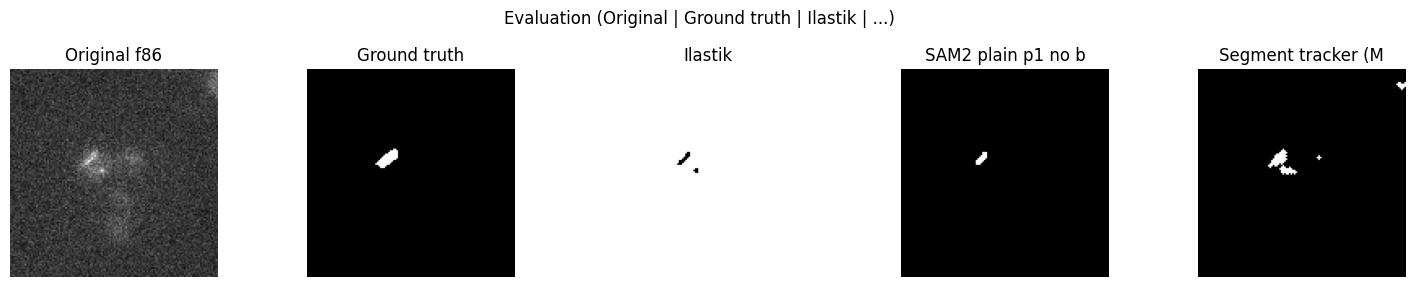

In [81]:
# Visualisation: animation of all frames, exportable as GIF
from matplotlib.animation import FuncAnimation, PillowWriter

n_frames = len(eval_records)
methods_to_show = list(methods.keys())
fig, axes = plt.subplots(1, 2 + len(methods_to_show), figsize=(3 * (2 + len(methods_to_show)), 3))
fig.suptitle("Evaluation (Original | Ground truth | Ilastik | ...)", y=1.02)

# Precompute predictions for all frames (for smooth animation)
preds_cache = {}
for i, rec in enumerate(eval_records):
    img_n = normalize_img(rec["image"])
    preds_cache[i] = {}
    for method_name, segment_fn in methods.items():
        if method_name == "Ilastik":
            im = rec.get("ilastik_mask")
            pred = (im.astype(np.uint8) if im.dtype != np.uint8 else im.copy()) if im is not None else np.zeros_like(img_n, dtype=np.uint8)
        elif segment_fn is not None:
            try:
                pred = segment_fn(img_n)
                if pred.dtype != np.uint8 and pred.dtype != bool:
                    pred = (pred > 0).astype(np.uint8)
            except Exception:
                pred = np.zeros_like(img_n, dtype=np.uint8)
        else:
            pred = np.zeros_like(img_n, dtype=np.uint8)
        preds_cache[i][method_name] = pred

def update(frame_idx):
    rec = eval_records[frame_idx]
    img_n = normalize_img(rec["image"])
    gt = rec["gt_mask"]
    if gt is None:
        gt = np.zeros_like(img_n, dtype=np.uint8)
    axes[0].clear()
    axes[0].imshow(img_n, cmap="gray")
    axes[0].set_title(f"Original f{rec['frame_index']}")
    axes[0].axis("off")
    axes[1].clear()
    axes[1].imshow(gt, cmap="gray")
    axes[1].set_title("Ground truth")
    axes[1].axis("off")
    for j, method_name in enumerate(methods_to_show):
        pred = preds_cache[frame_idx][method_name]
        axes[2 + j].clear()
        axes[2 + j].imshow(pred, cmap="gray")
        axes[2 + j].set_title(method_name[:18])
        axes[2 + j].axis("off")
    return axes

anim = FuncAnimation(fig, update, frames=n_frames, interval=300, blit=False)
plt.tight_layout()

# Export as GIF (save before show to ensure file is written)
gif_path = PROJECT_ROOT / "evaluation_comparison.gif"
writer = PillowWriter(fps=4)
anim.save(str(gif_path), writer=writer)
print(f"GIF saved to {gif_path}")

plt.show()


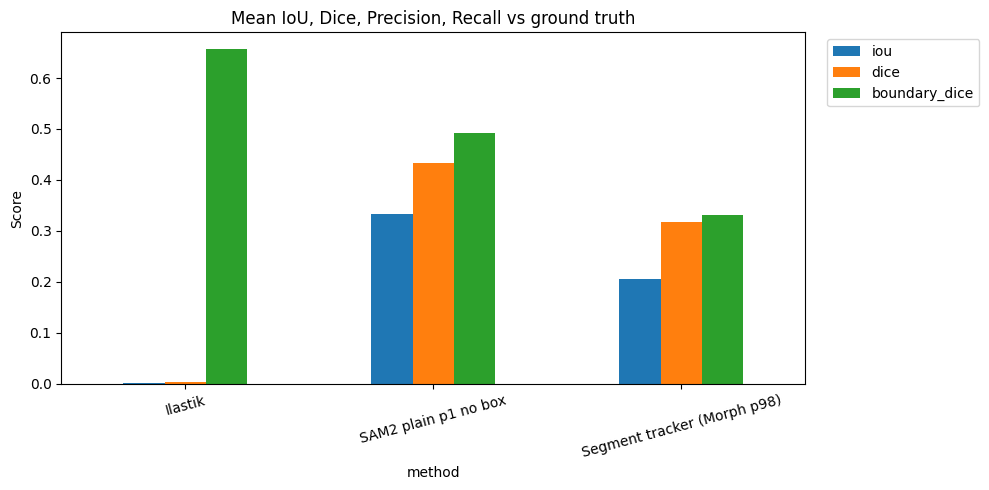

In [82]:
# Bar chart comparison
summary = eval_df.groupby("method")[["iou", "dice", "boundary_dice"]].mean()
summary.plot(kind="bar", figsize=(10, 5), rot=15)
plt.ylabel("Score")
plt.title("Mean IoU, Dice, Precision, Recall vs ground truth")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


---
## 12. Filament Length and Persistence Time

We estimate **filament length** by fitting an ellipse to each binary mask and taking the **major axis** as the length (in pixels). For **persistence time**, we use the full dataset `ch20_URA7_URA8_002-crop6.tif`: we find the longest *consecutive* run of frames where the filament is detected. If the filament appears, disappears, and reappears, we take the longest such run.

In [83]:
# Filament length (ellipse major axis) and persistence time
import imageio.v3 as iio
from skimage.measure import label, regionprops
from workflow.segmentation import MorphologicalSegmenter

# Dataset for persistence/time: ch20_URA7_URA8_002-crop6.tif
CROP6_TIFF = PROJECT_ROOT / "ch20_URA7_URA8_002-crop6.tif"
if not CROP6_TIFF.exists():
    CROP6_TIFF = PROJECT_ROOT.parent / "BioHackathon2026" / "ch20_URA7_URA8_002-crop6.tif"

segment_fn = lambda img: MorphologicalSegmenter(threshold_percentile=98, open_radius=1, close_radius=1).segment(img)

def ellipse_major_axis_length(mask):
    """Fit ellipse to mask, return major axis length (pixels). Uses largest connected component."""
    labeled = label(mask > 0)
    regions = regionprops(labeled)
    if not regions:
        return None
    # Take largest region (main filament)
    largest = max(regions, key=lambda r: r.area)
    return float(largest.axis_major_length)

def find_longest_consecutive_run(detected_frames):
    """From sorted list of frame indices where filament was detected, return (start, end, length) of longest run."""
    if not detected_frames:
        return None, None, 0
    frames = sorted(detected_frames)
    best_start, best_end, best_len = frames[0], frames[0], 1
    run_start, run_end = frames[0], frames[0]
    for f in frames[1:]:
        if f == run_end + 1:
            run_end = f
        else:
            run_len = run_end - run_start + 1
            if run_len > best_len:
                best_start, best_end, best_len = run_start, run_end, run_len
            run_start, run_end = f, f
    run_len = run_end - run_start + 1
    if run_len > best_len:
        best_start, best_end, best_len = run_start, run_end, run_len
    return best_start, best_end, best_len

# Load full TIFF and process all frames
frames_stack = iio.imread(CROP6_TIFF)
if frames_stack.ndim == 2:
    frames_stack = frames_stack[None, ...]
elif frames_stack.ndim == 3 and frames_stack.shape[-1] < min(frames_stack.shape[:2]):
    pass  # (T, H, W)
else:
    frames_stack = np.moveaxis(frames_stack, -1, 0)  # (T, H, W) if channel last

n_frames = frames_stack.shape[0]
lengths = []
detected_frame_indices = []
for i in range(n_frames):
    img = frames_stack[i]
    if img.ndim > 2:
        img = img[0] if img.shape[0] < img.shape[-1] else img[..., 0]
    img_n = np.asarray(img, dtype=np.float64)
    if img_n.max() > 1.0:
        img_n = img_n / img_n.max()
    pred = segment_fn(img_n)
    if pred.dtype != np.uint8:
        pred = (pred > 0).astype(np.uint8)
    if np.any(pred > 0):
        detected_frame_indices.append(i)
        L = ellipse_major_axis_length(pred)
        if L is not None:
            lengths.append(L)

first_frame, last_frame, persistence_frames = find_longest_consecutive_run(detected_frame_indices)
lengths_arr = np.array(lengths) if lengths else np.array([])

print(f"Persistence time: {persistence_frames} frames")
print(f"First frame (filament appears): {first_frame if first_frame is not None else 'N/A'}")
print(f"Last frame (filament stops): {last_frame if last_frame is not None else 'N/A'}")
if len(lengths_arr) > 0:
    print(f"Length stats (px): mean={lengths_arr.mean():.1f}, std={lengths_arr.std():.1f}, n={len(lengths_arr)}")
else:
    print("No filament detections; no length stats.")

Persistence time: 97 frames
First frame (filament appears): 30
Last frame (filament stops): 126
Length stats (px): mean=11.5, std=10.1, n=119


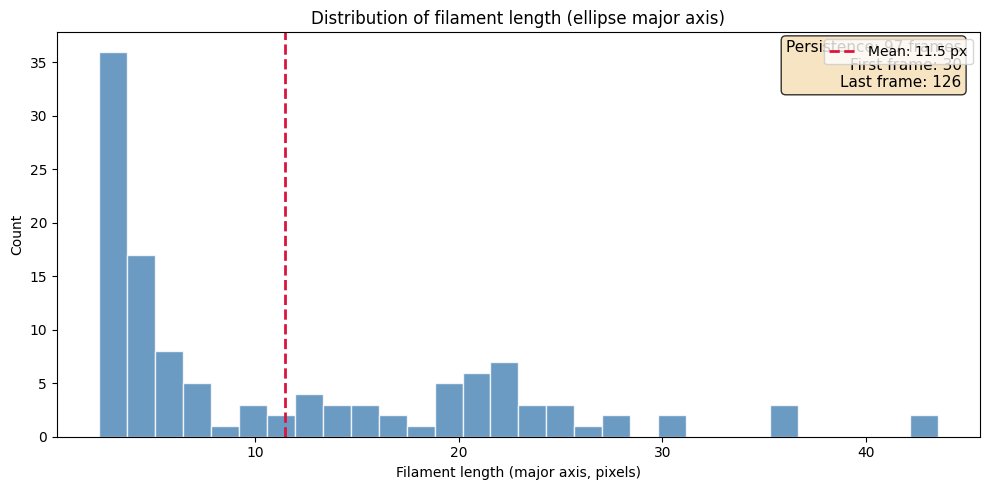

In [84]:
# Plot: length distribution + persistence time annotation
fig, ax = plt.subplots(figsize=(10, 5))
if len(lengths_arr) > 0:
    ax.hist(lengths_arr, bins=min(30, max(5, len(lengths_arr) // 2)), color="steelblue", edgecolor="white", alpha=0.8)
    ax.axvline(lengths_arr.mean(), color="crimson", linestyle="--", linewidth=2, label=f"Mean: {lengths_arr.mean():.1f} px")
ax.set_xlabel("Filament length (major axis, pixels)")
ax.set_ylabel("Count")
ax.set_title("Distribution of filament length (ellipse major axis)")
textstr = f"Persistence: {persistence_frames} frames\nFirst frame: {first_frame if first_frame is not None else 'N/A'}\nLast frame: {last_frame if last_frame is not None else 'N/A'}"
props = dict(boxstyle="round", facecolor="wheat", alpha=0.8)
ax.text(0.98, 0.98, textstr, transform=ax.transAxes, fontsize=11, verticalalignment="top", horizontalalignment="right", bbox=props)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()